In [1]:
import subprocess, sys

def _ensure(pkg, import_name=None):
    try:
        __import__(import_name or pkg)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

for _pkg, _mod in [('kagglehub', None), ('opencv-python-headless', 'cv2'),
                    ('seaborn', None), ('tabulate', None)]:
    _ensure(_pkg, _mod)

print("Packages ready.")

Packages ready.


In [2]:
import os, time, copy, json
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, balanced_accuracy_score,
                              confusion_matrix, classification_report)
from sklearn.preprocessing import label_binarize

In [3]:
HAM_CODE_TO_NAME = {
    'akiec': 'actinic keratoses', 'bcc': 'basal cell carcinoma',
    'bkl': 'benign keratosis-like lesions', 'df': 'dermatofibroma',
    'mel': 'melanoma', 'nv': 'melanocytic nevi', 'vasc': 'vascular lesions',
}
SELECTED_CODES = ['mel', 'nv', 'bcc', 'df', 'vasc']  # matches Task 01's 5-class subset

BEST_MODELS = ['AlexNet', 'ResNet50', 'DenseNet121']  # Keep the top-3 models from Task 01
FILTER_LABELS = {  # internal_name: display name (matches Task_02.docx table)
    'none': 'No Filter', 'average': 'Average', 'gaussian': 'Gaussian',
    'median': 'Median', 'sharpen': 'Sharpening', 'sobel': 'Sobel',
}

IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 6          # kept modest since this runs 18 full training loops
LR = 1e-4
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

SAVE_DIR = "./results_task02"
CM_DIR = os.path.join(SAVE_DIR, "confusion_matrices")
CURVE_DIR = os.path.join(SAVE_DIR, "curves")
for d in (SAVE_DIR, CM_DIR, CURVE_DIR):
    os.makedirs(d, exist_ok=True)

MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

# FILTER_LABELS is intentionally a dictionary:
# internal filter name -> display name used in the result tables.
assert isinstance(FILTER_LABELS, dict), "FILTER_LABELS must be a dictionary."
assert 'none' in FILTER_LABELS, "FILTER_LABELS must contain the 'none' baseline."


Device: cuda


In [4]:
import kagglehub

print("Downloading dataset (cached after first run)...")
DATASET_PATH = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
print("Dataset path:", DATASET_PATH)

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Dataset path: /kaggle/input/skin-cancer-mnist-ham10000


In [5]:
META_CSV = None
IMG_DIRS = []
for root, dirs, files in os.walk(DATASET_PATH):
    for f in files:
        if f.lower().endswith('.csv') and 'metadata' in f.lower():
            META_CSV = os.path.join(root, f)
        if f.lower().endswith('.jpg'):
            if root not in IMG_DIRS:
                IMG_DIRS.append(root)
            break

if META_CSV is None or not IMG_DIRS:
    raise FileNotFoundError(
        f"Could not auto-locate metadata CSV / image folders under {DATASET_PATH}. "
        f"Run `!find '{DATASET_PATH}'` in a cell to inspect the real layout and adjust this section."
    )
print("Metadata CSV:", META_CSV)
print("Image directories:", IMG_DIRS)

Metadata CSV: /kaggle/input/skin-cancer-mnist-ham10000/HAM10000_metadata.csv
Image directories: ['/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1', '/kaggle/input/skin-cancer-mnist-ham10000/ham10000_images_part_1', '/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_2', '/kaggle/input/skin-cancer-mnist-ham10000/ham10000_images_part_2']


In [6]:
meta_df = pd.read_csv(META_CSV)  # columns: lesion_id, image_id, dx, dx_type, age, sex, localization
meta_df['label_code'] = meta_df['dx']

df = meta_df[meta_df['label_code'].isin(SELECTED_CODES)][['image_id', 'label_code']].reset_index(drop=True)
df = df.rename(columns={'image_id': 'image'})
classes = sorted(SELECTED_CODES)  # dx codes, alphabetical -> stable label indices
class_to_idx = {c: i for i, c in enumerate(classes)}
class_names_readable = [HAM_CODE_TO_NAME[c] for c in classes]
NUM_CLASSES = len(classes)

print(f"Using {NUM_CLASSES} classes: {list(zip(classes, class_names_readable))}")
print("Class distribution:")
print(df['label_code'].value_counts())

Using 5 classes: [('bcc', 'basal cell carcinoma'), ('df', 'dermatofibroma'), ('mel', 'melanoma'), ('nv', 'melanocytic nevi'), ('vasc', 'vascular lesions')]
Class distribution:
label_code
nv      6705
mel     1113
bcc      514
vasc     142
df       115
Name: count, dtype: int64


In [7]:
train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df['label_code'], random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label_code'], random_state=SEED)
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 6871 | Val: 859 | Test: 859


In [8]:
def resolve_image_path(image_id):
    for img_dir in IMG_DIRS:
        for ext in ('.jpg', '.jpeg', '.png'):
            p = os.path.join(img_dir, image_id + ext)
            if os.path.exists(p):
                return p
    return os.path.join(IMG_DIRS[0], image_id + '.jpg')  # best-effort default

In [9]:
def apply_filter(img_np, filter_name):
    """img_np: HxWx3 uint8 RGB array. Returns filtered HxWx3 uint8 RGB array."""
    if filter_name == 'none':
        return img_np
    if filter_name == 'average':
        return cv2.blur(img_np, (5, 5))
    if filter_name == 'gaussian':
        return cv2.GaussianBlur(img_np, (5, 5), 0)
    if filter_name == 'median':
        return cv2.medianBlur(img_np, 5)
    if filter_name == 'sharpen':
        kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
        return cv2.filter2D(img_np, -1, kernel)
    if filter_name == 'sobel':
        gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
        gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
        gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
        mag = cv2.magnitude(gx, gy)
        mag = np.clip(mag / mag.max() * 255 if mag.max() > 0 else mag, 0, 255).astype(np.uint8)
        return cv2.cvtColor(mag, cv2.COLOR_GRAY2RGB)
    raise ValueError(f"Unknown filter: {filter_name}")

In [10]:
class FilterTransform:
    """Applies a named filter to a PIL image; drop-in for transforms.Compose."""
    def __init__(self, filter_name):
        self.filter_name = filter_name

    def __call__(self, pil_img):
        arr = np.array(pil_img.convert('RGB'))
        filtered = apply_filter(arr, self.filter_name)
        return Image.fromarray(filtered)


def build_transforms(filter_name, train=True):
    ops = [transforms.Resize((IMG_SIZE, IMG_SIZE))]
    if train:
        ops += [transforms.RandomHorizontalFlip(), transforms.RandomVerticalFlip()]
    ops += [FilterTransform(filter_name), transforms.ToTensor(), transforms.Normalize(MEAN, STD)]
    return transforms.Compose(ops)

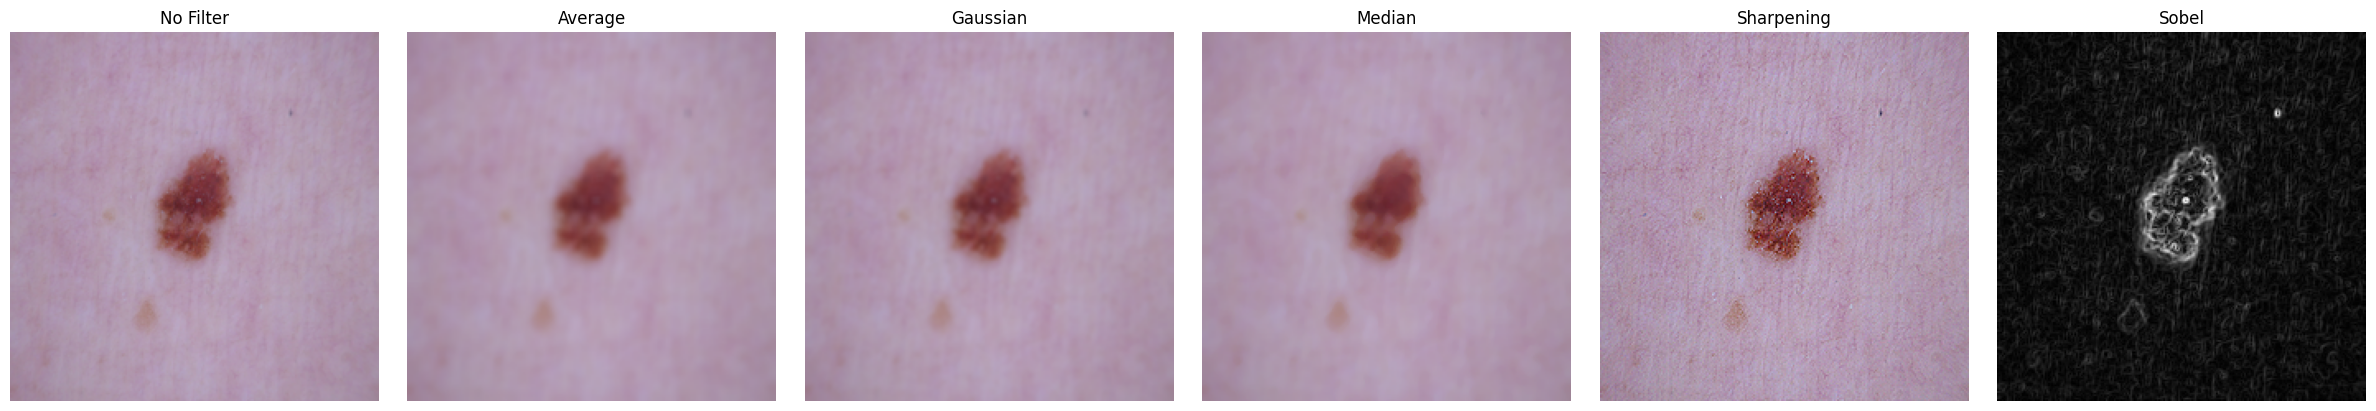

In [11]:
def plot_filter_examples():
    sample_path = resolve_image_path(df.iloc[0]['image'])
    img = np.array(Image.open(sample_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE)))
    fig, axes = plt.subplots(1, len(FILTER_LABELS), figsize=(4 * len(FILTER_LABELS), 4))
    for ax, (fname, flabel) in zip(axes, FILTER_LABELS.items()):
        ax.imshow(apply_filter(img, fname))
        ax.set_title(flabel)
        ax.axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, "filter_examples.png"), dpi=120)
    plt.show()

plot_filter_examples()

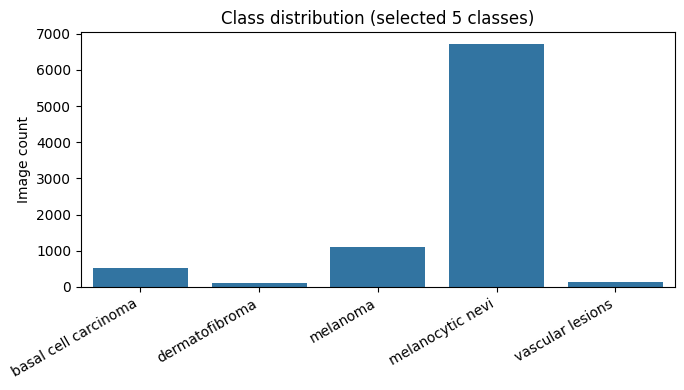

In [12]:
def plot_class_distribution():
    counts = df['label_code'].value_counts().reindex(classes)
    plt.figure(figsize=(7, 4))
    sns.barplot(x=[HAM_CODE_TO_NAME[c] for c in counts.index], y=counts.values)
    plt.title("Class distribution (selected 5 classes)")
    plt.ylabel("Image count")
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, "class_distribution.png"), dpi=120)
    plt.show()

plot_class_distribution()

In [13]:
class ISICDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(resolve_image_path(row['image'])).convert('RGB')
        img = self.transform(img)
        label = class_to_idx[row['label_code']]
        return img, label


def make_loaders(filter_name):
    train_ds = ISICDataset(train_df, build_transforms(filter_name, train=True))
    val_ds = ISICDataset(val_df, build_transforms(filter_name, train=False))
    test_ds = ISICDataset(test_df, build_transforms(filter_name, train=False))
    return (DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2),
            DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2),
            DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2))

In [14]:
def get_model(name):
    n = name.lower().replace('-', '').replace('_', '')
    if n == 'alexnet':
        m = models.alexnet(weights=models.AlexNet_Weights.DEFAULT)
        m.classifier[6] = nn.Linear(4096, NUM_CLASSES)
    elif n == 'vgg16':
        m = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
        m.classifier[6] = nn.Linear(4096, NUM_CLASSES)
    elif n == 'vgg19':
        m = models.vgg19(weights=models.VGG19_Weights.DEFAULT)
        m.classifier[6] = nn.Linear(4096, NUM_CLASSES)
    elif n == 'resnet18':
        m = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        m.fc = nn.Linear(m.fc.in_features, NUM_CLASSES)
    elif n == 'resnet50':
        m = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        m.fc = nn.Linear(m.fc.in_features, NUM_CLASSES)
    elif n == 'resnet101':
        m = models.resnet101(weights=models.ResNet101_Weights.DEFAULT)
        m.fc = nn.Linear(m.fc.in_features, NUM_CLASSES)
    elif n == 'densenet121':
        m = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
        m.classifier = nn.Linear(m.classifier.in_features, NUM_CLASSES)
    elif n == 'efficientnetb0':
        m = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, NUM_CLASSES)
    else:
        raise ValueError(f"Unknown model: {name}")
    return m

In [15]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = correct = total = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct += (out.argmax(1) == labels).sum().item()
        total += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = correct = total = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        out = model(imgs)
        loss = criterion(out, labels)
        total_loss += loss.item() * imgs.size(0)
        correct += (out.argmax(1) == labels).sum().item()
        total += imgs.size(0)
    return total_loss / total, correct / total

In [16]:
def train_model(model, train_loader, val_loader, tag):
    """Trains for EPOCHS, tracks curves, returns best-val-acc weights + history."""
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LR)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc, best_state = 0.0, None

    for ep in range(1, EPOCHS + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer)
        vl_loss, vl_acc = eval_epoch(model, val_loader, criterion)
        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(vl_loss)
        history['val_acc'].append(vl_acc)
        print(f"  [{tag}] Ep {ep}/{EPOCHS} | train_loss={tr_loss:.3f} train_acc={tr_acc:.3f} "
              f"| val_loss={vl_loss:.3f} val_acc={vl_acc:.3f}")
        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            best_state = copy.deepcopy(model.state_dict())

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history


In [17]:
@torch.no_grad()
def evaluate_full(model, loader):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    for imgs, labels in loader:
        imgs = imgs.to(DEVICE)
        out = model(imgs)
        probs = torch.softmax(out, dim=1).cpu().numpy()
        preds = probs.argmax(axis=1)
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
        all_probs.append(probs)

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.concatenate(all_probs, axis=0)

    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    rec = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    bal_acc = balanced_accuracy_score(all_labels, all_preds)
    try:
        y_bin = label_binarize(all_labels, classes=list(range(NUM_CLASSES)))
        auc = roc_auc_score(y_bin, all_probs, average='macro', multi_class='ovr')
    except ValueError:
        auc = float('nan')

    per_class = classification_report(all_labels, all_preds, target_names=classes,
                                       output_dict=True, zero_division=0)
    cm = confusion_matrix(all_labels, all_preds, labels=list(range(NUM_CLASSES)))

    metrics = {
        'Accuracy': round(acc * 100, 2), 'Precision': round(prec * 100, 2),
        'Recall': round(rec * 100, 2), 'F1-score': round(f1 * 100, 2),
        'Macro-F1': round(macro_f1 * 100, 2), 'Balanced Accuracy': round(bal_acc * 100, 2),
        'AUC': round(auc * 100, 2) if not np.isnan(auc) else 'N/A',
    }
    return metrics, per_class, cm

In [18]:
def plot_confusion_matrix(cm, model_name, filter_name):
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title(f"{model_name} — {FILTER_LABELS[filter_name]}")
    plt.ylabel("True"); plt.xlabel("Predicted")
    plt.tight_layout()
    fname = f"{model_name}_{filter_name}.png".replace(' ', '_')
    plt.savefig(os.path.join(CM_DIR, fname), dpi=120)
    plt.show()


def plot_curves(history, model_name, filter_name):
    epochs_range = range(1, len(history['train_acc']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(epochs_range, history['train_acc'], label='train')
    axes[0].plot(epochs_range, history['val_acc'], label='val')
    axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].legend()
    axes[1].plot(epochs_range, history['train_loss'], label='train')
    axes[1].plot(epochs_range, history['val_loss'], label='val')
    axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch'); axes[1].legend()
    plt.suptitle(f"{model_name} — {FILTER_LABELS[filter_name]}")
    plt.tight_layout()
    fname = f"{model_name}_{filter_name}.png".replace(' ', '_')
    plt.savefig(os.path.join(CURVE_DIR, fname), dpi=120)
    plt.show()

In [19]:
# ============================================================
# Experiment function
# ============================================================

results_rows = []
per_class_records = []


def run_experiment(model_name, filter_name):
    if model_name not in BEST_MODELS:
        raise ValueError(f"Unknown model in BEST_MODELS: {model_name}")

    if filter_name not in FILTER_LABELS:
        raise ValueError(
            f"Unknown filter: {filter_name}. "
            f"Available filters: {list(FILTER_LABELS.keys())}"
        )

    filter_label = FILTER_LABELS[filter_name]
    tag = f"{model_name} | {filter_label}"

    print(f"\n{'=' * 70}")
    print(f"  {tag}")
    print(f"{'=' * 70}")

    train_loader, val_loader, test_loader = make_loaders(filter_name)

    model = get_model(model_name)
    model, history = train_model(
        model,
        train_loader,
        val_loader,
        tag
    )

    metrics, per_class, cm = evaluate_full(
        model,
        test_loader
    )

    print(f"  RESULT -> {metrics}")

    results_rows.append({
        'Model': model_name,
        'Filter': filter_label,
        **metrics
    })

    for cls_name, cls_metrics in per_class.items():
        if cls_name in classes:
            per_class_records.append({
                'Model': model_name,
                'Filter': filter_label,
                'Class': HAM_CODE_TO_NAME[cls_name],
                'Precision': round(cls_metrics['precision'] * 100, 2),
                'Recall': round(cls_metrics['recall'] * 100, 2),
                'F1-score': round(cls_metrics['f1-score'] * 100, 2),
            })

    plot_confusion_matrix(
        cm,
        model_name,
        filter_name
    )

    plot_curves(
        history,
        model_name,
        filter_name
    )

    del model

    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()



  AlexNet | No Filter
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 125MB/s]


  [AlexNet | No Filter] Ep 1/6 | train_loss=0.474 train_acc=0.819 | val_loss=0.449 val_acc=0.815
  [AlexNet | No Filter] Ep 2/6 | train_loss=0.376 train_acc=0.856 | val_loss=0.362 val_acc=0.867
  [AlexNet | No Filter] Ep 3/6 | train_loss=0.340 train_acc=0.866 | val_loss=0.324 val_acc=0.870
  [AlexNet | No Filter] Ep 4/6 | train_loss=0.305 train_acc=0.881 | val_loss=0.405 val_acc=0.864
  [AlexNet | No Filter] Ep 5/6 | train_loss=0.280 train_acc=0.892 | val_loss=0.303 val_acc=0.891
  [AlexNet | No Filter] Ep 6/6 | train_loss=0.270 train_acc=0.894 | val_loss=0.311 val_acc=0.884
  RESULT -> {'Accuracy': 87.89, 'Precision': 87.35, 'Recall': 87.89, 'F1-score': 87.15, 'Macro-F1': 72.78, 'Balanced Accuracy': np.float64(72.73), 'AUC': np.float64(96.77)}


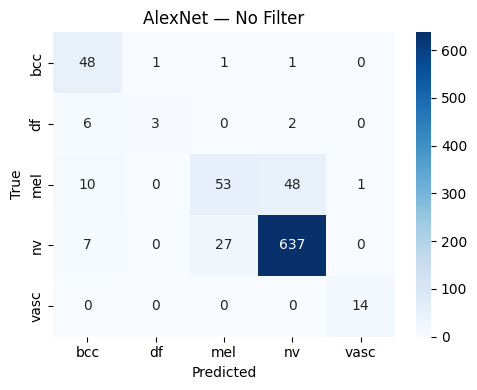

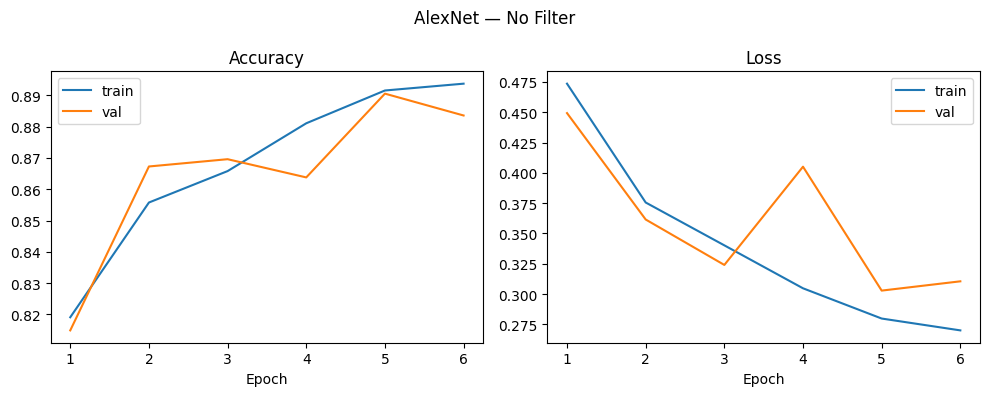


  ResNet50 | No Filter
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 213MB/s]


  [ResNet50 | No Filter] Ep 1/6 | train_loss=0.478 train_acc=0.832 | val_loss=0.367 val_acc=0.859
  [ResNet50 | No Filter] Ep 2/6 | train_loss=0.291 train_acc=0.890 | val_loss=0.291 val_acc=0.892
  [ResNet50 | No Filter] Ep 3/6 | train_loss=0.236 train_acc=0.911 | val_loss=0.323 val_acc=0.871
  [ResNet50 | No Filter] Ep 4/6 | train_loss=0.195 train_acc=0.927 | val_loss=0.300 val_acc=0.902
  [ResNet50 | No Filter] Ep 5/6 | train_loss=0.155 train_acc=0.941 | val_loss=0.276 val_acc=0.915
  [ResNet50 | No Filter] Ep 6/6 | train_loss=0.133 train_acc=0.952 | val_loss=0.288 val_acc=0.917
  RESULT -> {'Accuracy': 91.39, 'Precision': 90.99, 'Recall': 91.39, 'F1-score': 90.66, 'Macro-F1': 79.77, 'Balanced Accuracy': np.float64(75.38), 'AUC': np.float64(97.18)}


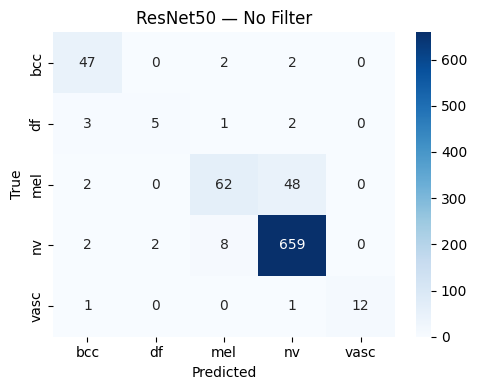

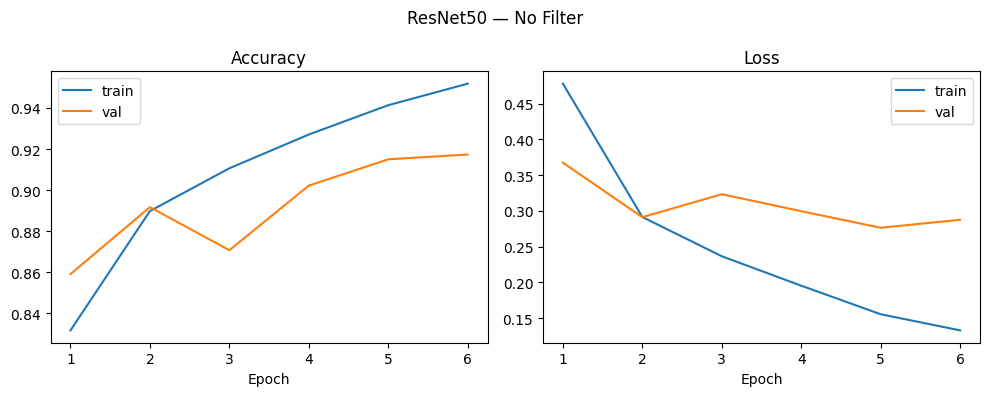


  DenseNet121 | No Filter
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 199MB/s]


  [DenseNet121 | No Filter] Ep 1/6 | train_loss=0.430 train_acc=0.849 | val_loss=0.350 val_acc=0.864
  [DenseNet121 | No Filter] Ep 2/6 | train_loss=0.284 train_acc=0.892 | val_loss=0.268 val_acc=0.901
  [DenseNet121 | No Filter] Ep 3/6 | train_loss=0.236 train_acc=0.908 | val_loss=0.228 val_acc=0.919
  [DenseNet121 | No Filter] Ep 4/6 | train_loss=0.192 train_acc=0.925 | val_loss=0.243 val_acc=0.917
  [DenseNet121 | No Filter] Ep 5/6 | train_loss=0.168 train_acc=0.938 | val_loss=0.358 val_acc=0.872
  [DenseNet121 | No Filter] Ep 6/6 | train_loss=0.148 train_acc=0.943 | val_loss=0.241 val_acc=0.919
  RESULT -> {'Accuracy': 90.69, 'Precision': 90.63, 'Recall': 90.69, 'F1-score': 90.51, 'Macro-F1': 79.58, 'Balanced Accuracy': np.float64(82.1), 'AUC': np.float64(97.63)}


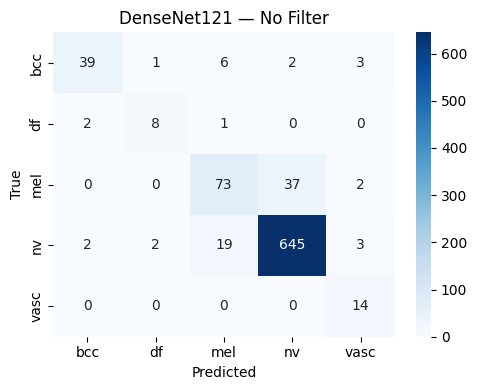

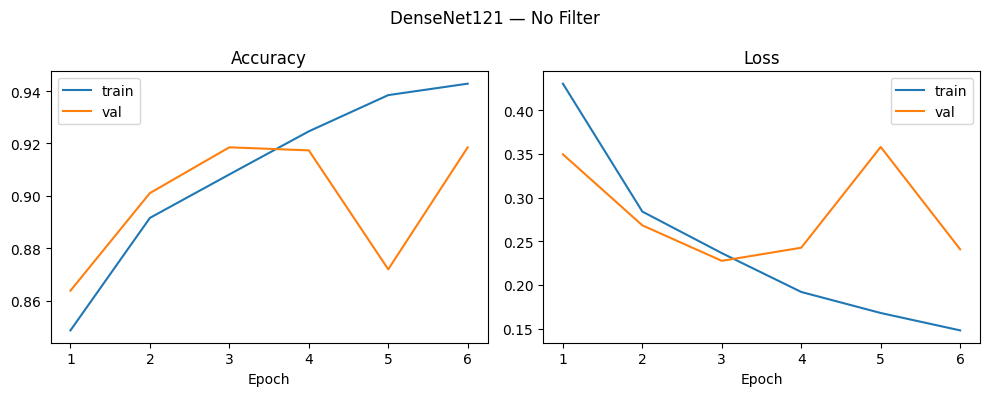


  AlexNet | Average
  [AlexNet | Average] Ep 1/6 | train_loss=0.471 train_acc=0.821 | val_loss=0.410 val_acc=0.841
  [AlexNet | Average] Ep 2/6 | train_loss=0.388 train_acc=0.853 | val_loss=0.388 val_acc=0.860
  [AlexNet | Average] Ep 3/6 | train_loss=0.347 train_acc=0.863 | val_loss=0.401 val_acc=0.827
  [AlexNet | Average] Ep 4/6 | train_loss=0.326 train_acc=0.873 | val_loss=0.316 val_acc=0.875
  [AlexNet | Average] Ep 5/6 | train_loss=0.305 train_acc=0.882 | val_loss=0.324 val_acc=0.866
  [AlexNet | Average] Ep 6/6 | train_loss=0.278 train_acc=0.892 | val_loss=0.316 val_acc=0.885
  RESULT -> {'Accuracy': 88.82, 'Precision': 88.2, 'Recall': 88.82, 'F1-score': 88.11, 'Macro-F1': 72.6, 'Balanced Accuracy': np.float64(73.03), 'AUC': np.float64(97.17)}


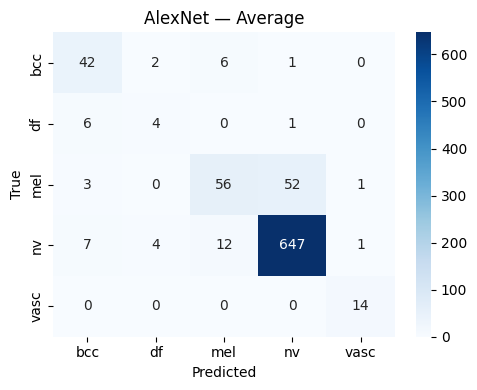

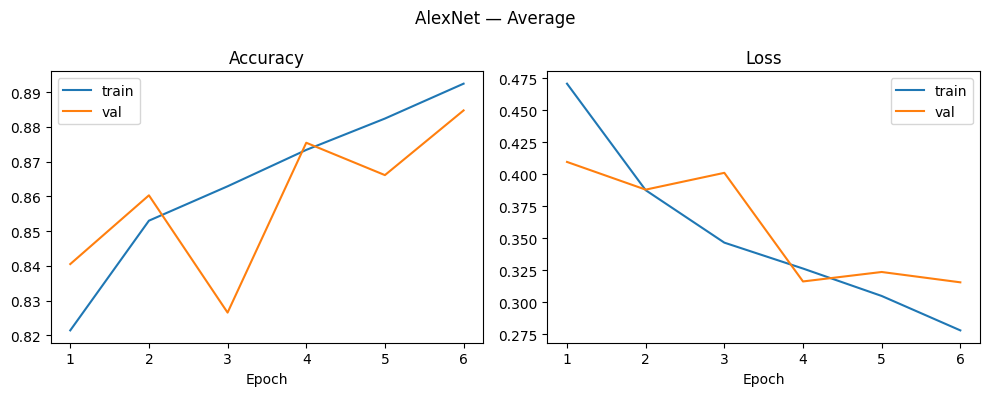


  AlexNet | Gaussian
  [AlexNet | Gaussian] Ep 1/6 | train_loss=0.496 train_acc=0.816 | val_loss=0.389 val_acc=0.843
  [AlexNet | Gaussian] Ep 2/6 | train_loss=0.389 train_acc=0.848 | val_loss=0.387 val_acc=0.857
  [AlexNet | Gaussian] Ep 3/6 | train_loss=0.346 train_acc=0.866 | val_loss=0.348 val_acc=0.868
  [AlexNet | Gaussian] Ep 4/6 | train_loss=0.325 train_acc=0.875 | val_loss=0.368 val_acc=0.851
  [AlexNet | Gaussian] Ep 5/6 | train_loss=0.308 train_acc=0.883 | val_loss=0.331 val_acc=0.873
  [AlexNet | Gaussian] Ep 6/6 | train_loss=0.277 train_acc=0.889 | val_loss=0.342 val_acc=0.874
  RESULT -> {'Accuracy': 88.13, 'Precision': 87.31, 'Recall': 88.13, 'F1-score': 86.57, 'Macro-F1': 74.21, 'Balanced Accuracy': np.float64(72.17), 'AUC': np.float64(97.19)}


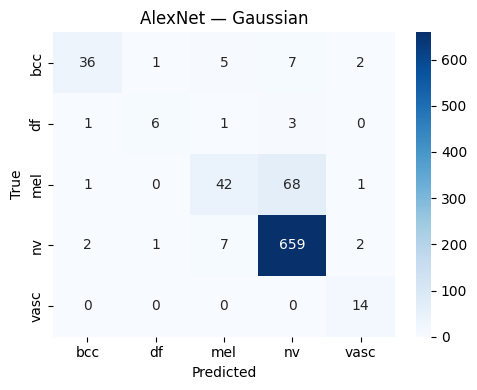

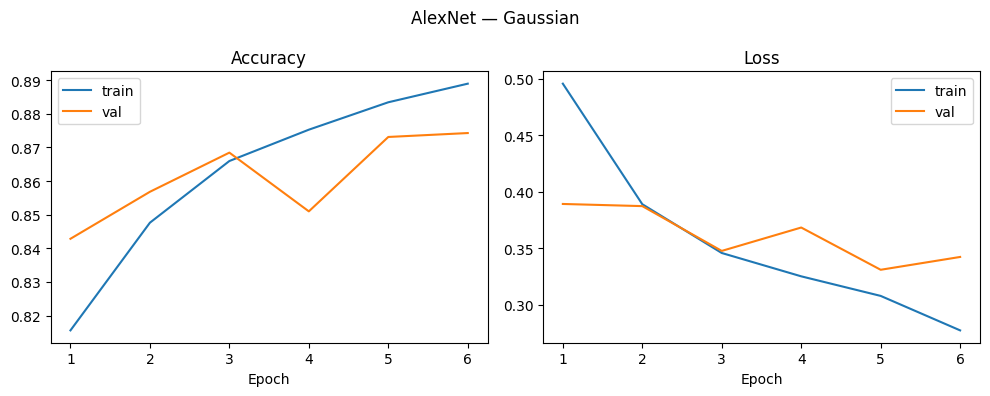


  AlexNet | Median
  [AlexNet | Median] Ep 1/6 | train_loss=0.466 train_acc=0.822 | val_loss=0.397 val_acc=0.857
  [AlexNet | Median] Ep 2/6 | train_loss=0.401 train_acc=0.846 | val_loss=0.365 val_acc=0.853
  [AlexNet | Median] Ep 3/6 | train_loss=0.355 train_acc=0.867 | val_loss=0.380 val_acc=0.854
  [AlexNet | Median] Ep 4/6 | train_loss=0.337 train_acc=0.871 | val_loss=0.424 val_acc=0.847
  [AlexNet | Median] Ep 5/6 | train_loss=0.310 train_acc=0.883 | val_loss=0.327 val_acc=0.880
  [AlexNet | Median] Ep 6/6 | train_loss=0.286 train_acc=0.893 | val_loss=0.407 val_acc=0.854
  RESULT -> {'Accuracy': 88.59, 'Precision': 87.58, 'Recall': 88.59, 'F1-score': 87.94, 'Macro-F1': 62.88, 'Balanced Accuracy': np.float64(68.32), 'AUC': np.float64(97.06)}


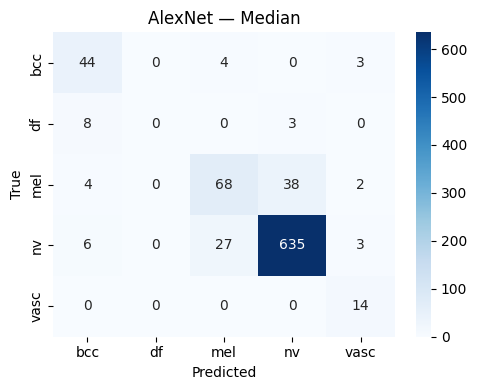

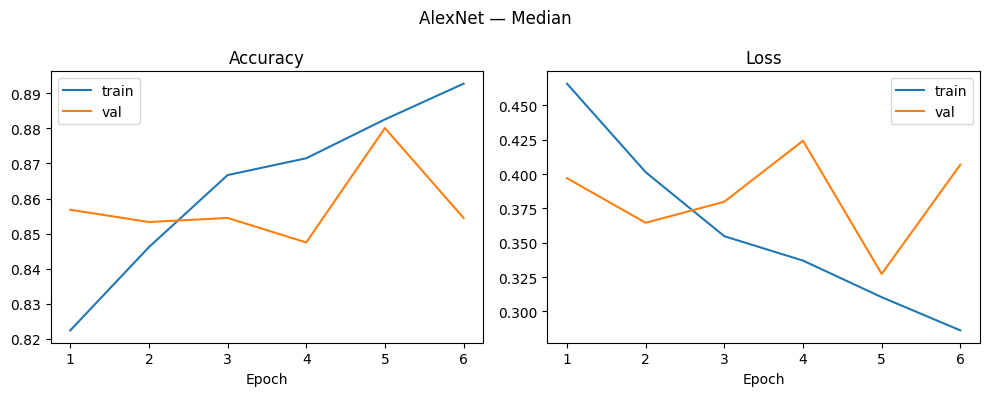


  AlexNet | Sharpening
  [AlexNet | Sharpening] Ep 1/6 | train_loss=0.508 train_acc=0.811 | val_loss=0.391 val_acc=0.858
  [AlexNet | Sharpening] Ep 2/6 | train_loss=0.402 train_acc=0.845 | val_loss=0.381 val_acc=0.872
  [AlexNet | Sharpening] Ep 3/6 | train_loss=0.358 train_acc=0.867 | val_loss=0.350 val_acc=0.880
  [AlexNet | Sharpening] Ep 4/6 | train_loss=0.324 train_acc=0.875 | val_loss=0.386 val_acc=0.853
  [AlexNet | Sharpening] Ep 5/6 | train_loss=0.301 train_acc=0.881 | val_loss=0.326 val_acc=0.875
  [AlexNet | Sharpening] Ep 6/6 | train_loss=0.278 train_acc=0.893 | val_loss=0.297 val_acc=0.885
  RESULT -> {'Accuracy': 88.36, 'Precision': 87.85, 'Recall': 88.36, 'F1-score': 87.96, 'Macro-F1': 73.45, 'Balanced Accuracy': np.float64(71.31), 'AUC': np.float64(96.75)}


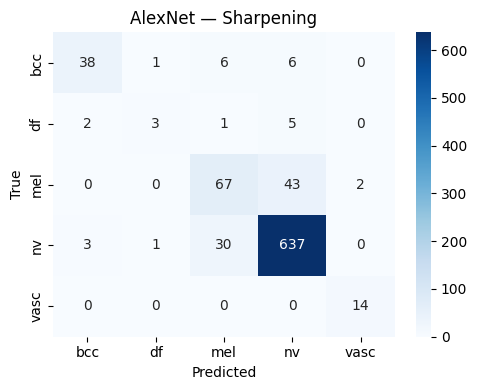

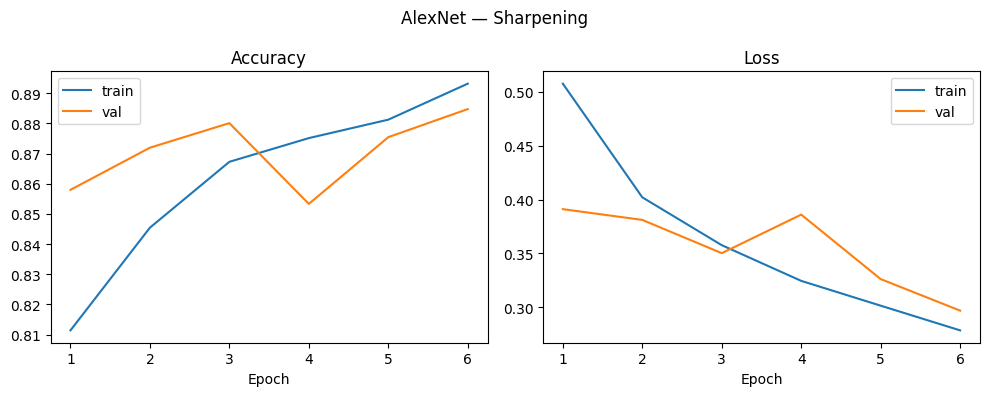


  AlexNet | Sobel
  [AlexNet | Sobel] Ep 1/6 | train_loss=0.720 train_acc=0.780 | val_loss=0.647 val_acc=0.783
  [AlexNet | Sobel] Ep 2/6 | train_loss=0.625 train_acc=0.788 | val_loss=0.592 val_acc=0.799
  [AlexNet | Sobel] Ep 3/6 | train_loss=0.568 train_acc=0.800 | val_loss=0.641 val_acc=0.800
  [AlexNet | Sobel] Ep 4/6 | train_loss=0.551 train_acc=0.805 | val_loss=0.663 val_acc=0.795
  [AlexNet | Sobel] Ep 5/6 | train_loss=0.518 train_acc=0.815 | val_loss=0.557 val_acc=0.811
  [AlexNet | Sobel] Ep 6/6 | train_loss=0.503 train_acc=0.814 | val_loss=0.568 val_acc=0.815
  RESULT -> {'Accuracy': 81.14, 'Precision': 78.29, 'Recall': 81.14, 'F1-score': 76.94, 'Macro-F1': 39.26, 'Balanced Accuracy': np.float64(34.72), 'AUC': np.float64(86.18)}


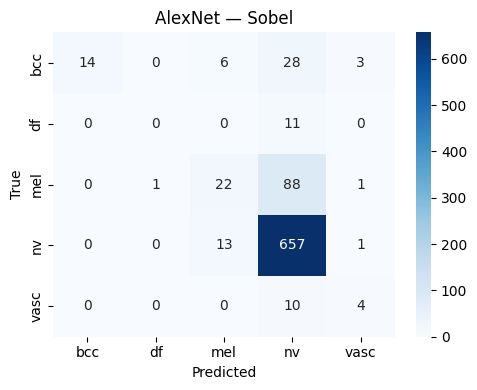

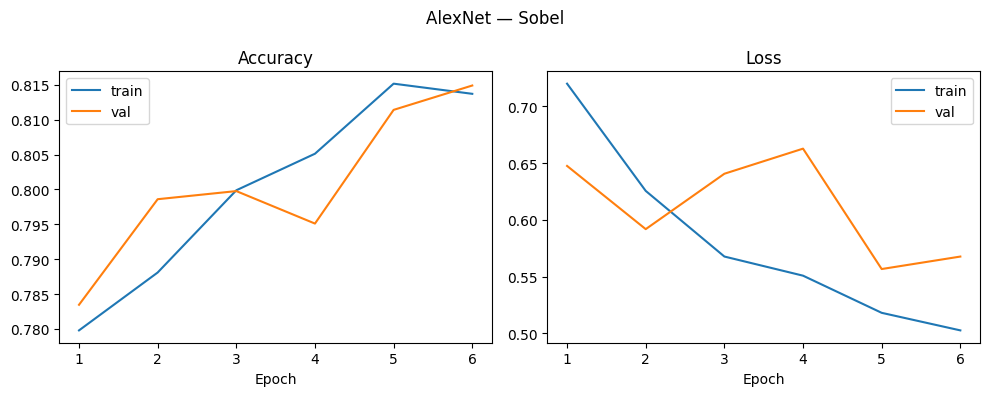


  ResNet50 | Average
  [ResNet50 | Average] Ep 1/6 | train_loss=0.490 train_acc=0.825 | val_loss=0.333 val_acc=0.880
  [ResNet50 | Average] Ep 2/6 | train_loss=0.329 train_acc=0.877 | val_loss=0.312 val_acc=0.878
  [ResNet50 | Average] Ep 3/6 | train_loss=0.283 train_acc=0.890 | val_loss=0.318 val_acc=0.886
  [ResNet50 | Average] Ep 4/6 | train_loss=0.237 train_acc=0.909 | val_loss=0.268 val_acc=0.893
  [ResNet50 | Average] Ep 5/6 | train_loss=0.201 train_acc=0.924 | val_loss=0.302 val_acc=0.901
  [ResNet50 | Average] Ep 6/6 | train_loss=0.183 train_acc=0.929 | val_loss=0.264 val_acc=0.920
  RESULT -> {'Accuracy': 89.41, 'Precision': 89.67, 'Recall': 89.41, 'F1-score': 89.37, 'Macro-F1': 80.05, 'Balanced Accuracy': np.float64(80.95), 'AUC': np.float64(97.4)}


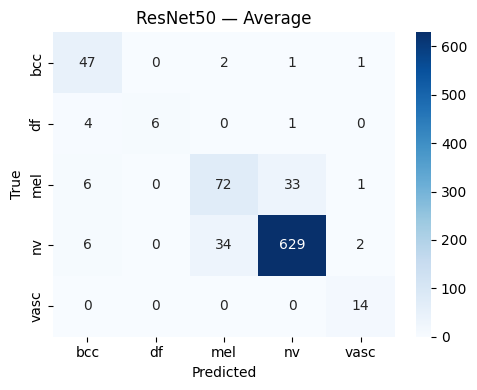

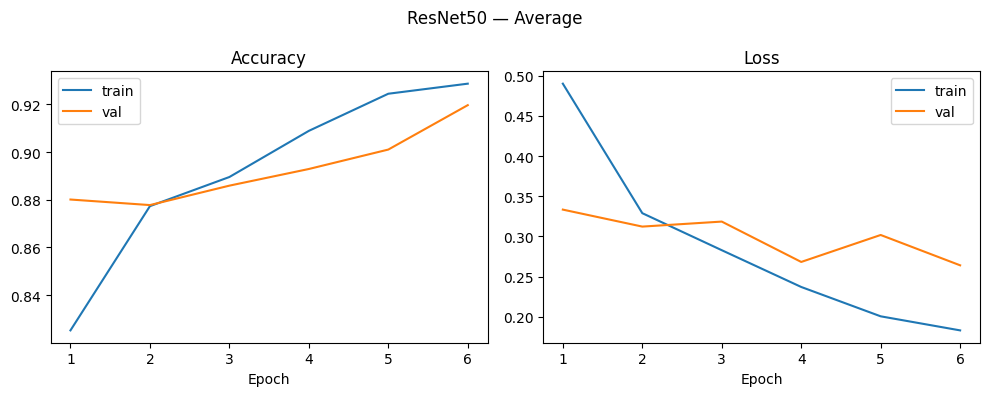


  ResNet50 | Gaussian
  [ResNet50 | Gaussian] Ep 1/6 | train_loss=0.498 train_acc=0.829 | val_loss=0.356 val_acc=0.858
  [ResNet50 | Gaussian] Ep 2/6 | train_loss=0.308 train_acc=0.887 | val_loss=0.304 val_acc=0.884
  [ResNet50 | Gaussian] Ep 3/6 | train_loss=0.260 train_acc=0.899 | val_loss=0.303 val_acc=0.891
  [ResNet50 | Gaussian] Ep 4/6 | train_loss=0.212 train_acc=0.920 | val_loss=0.305 val_acc=0.889
  [ResNet50 | Gaussian] Ep 5/6 | train_loss=0.189 train_acc=0.928 | val_loss=0.327 val_acc=0.895
  [ResNet50 | Gaussian] Ep 6/6 | train_loss=0.163 train_acc=0.935 | val_loss=0.303 val_acc=0.894
  RESULT -> {'Accuracy': 90.57, 'Precision': 89.88, 'Recall': 90.57, 'F1-score': 89.66, 'Macro-F1': 83.48, 'Balanced Accuracy': np.float64(79.99), 'AUC': np.float64(97.62)}


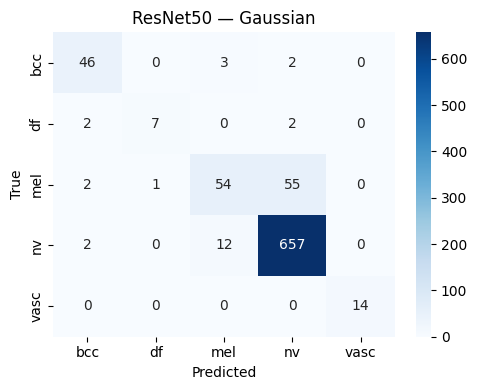

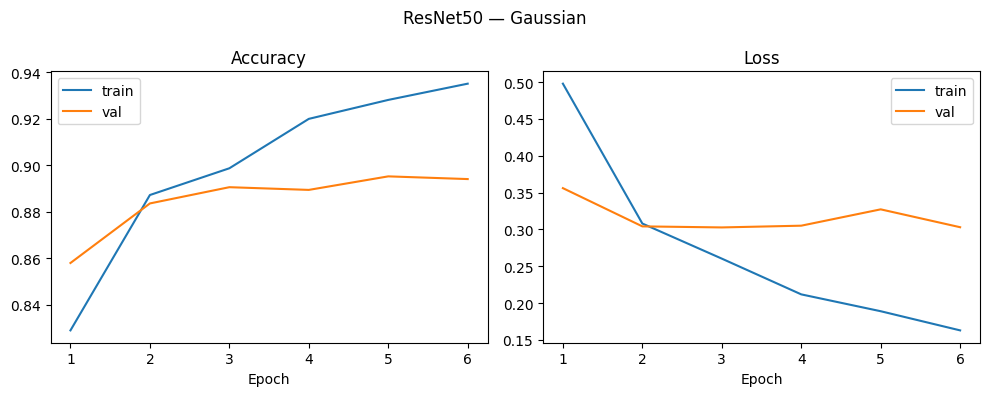


  ResNet50 | Median
  [ResNet50 | Median] Ep 1/6 | train_loss=0.487 train_acc=0.828 | val_loss=0.405 val_acc=0.849
  [ResNet50 | Median] Ep 2/6 | train_loss=0.321 train_acc=0.875 | val_loss=0.354 val_acc=0.868
  [ResNet50 | Median] Ep 3/6 | train_loss=0.279 train_acc=0.894 | val_loss=0.296 val_acc=0.894
  [ResNet50 | Median] Ep 4/6 | train_loss=0.222 train_acc=0.916 | val_loss=0.276 val_acc=0.893
  [ResNet50 | Median] Ep 5/6 | train_loss=0.200 train_acc=0.924 | val_loss=0.360 val_acc=0.886
  [ResNet50 | Median] Ep 6/6 | train_loss=0.184 train_acc=0.929 | val_loss=0.309 val_acc=0.901
  RESULT -> {'Accuracy': 91.27, 'Precision': 90.83, 'Recall': 91.27, 'F1-score': 90.52, 'Macro-F1': 79.9, 'Balanced Accuracy': np.float64(77.27), 'AUC': np.float64(97.48)}


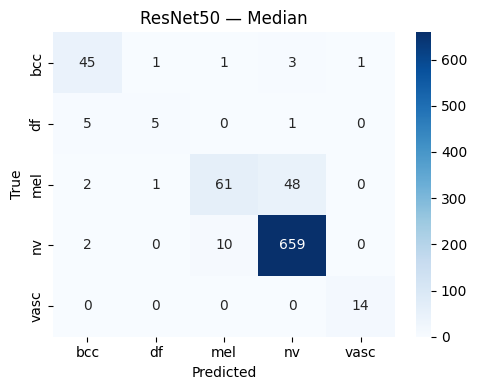

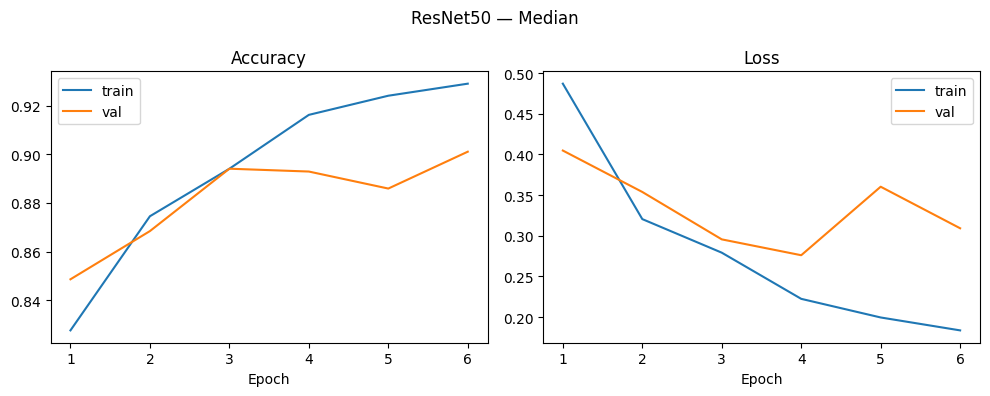


  ResNet50 | Sharpening
  [ResNet50 | Sharpening] Ep 1/6 | train_loss=0.477 train_acc=0.834 | val_loss=0.371 val_acc=0.858
  [ResNet50 | Sharpening] Ep 2/6 | train_loss=0.297 train_acc=0.888 | val_loss=0.286 val_acc=0.884
  [ResNet50 | Sharpening] Ep 3/6 | train_loss=0.227 train_acc=0.915 | val_loss=0.267 val_acc=0.905
  [ResNet50 | Sharpening] Ep 4/6 | train_loss=0.172 train_acc=0.939 | val_loss=0.333 val_acc=0.881
  [ResNet50 | Sharpening] Ep 5/6 | train_loss=0.149 train_acc=0.946 | val_loss=0.305 val_acc=0.900
  [ResNet50 | Sharpening] Ep 6/6 | train_loss=0.131 train_acc=0.953 | val_loss=0.251 val_acc=0.915
  RESULT -> {'Accuracy': 91.97, 'Precision': 91.73, 'Recall': 91.97, 'F1-score': 91.6, 'Macro-F1': 82.27, 'Balanced Accuracy': np.float64(82.52), 'AUC': np.float64(97.26)}


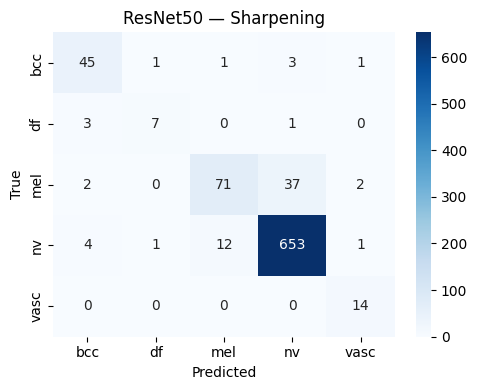

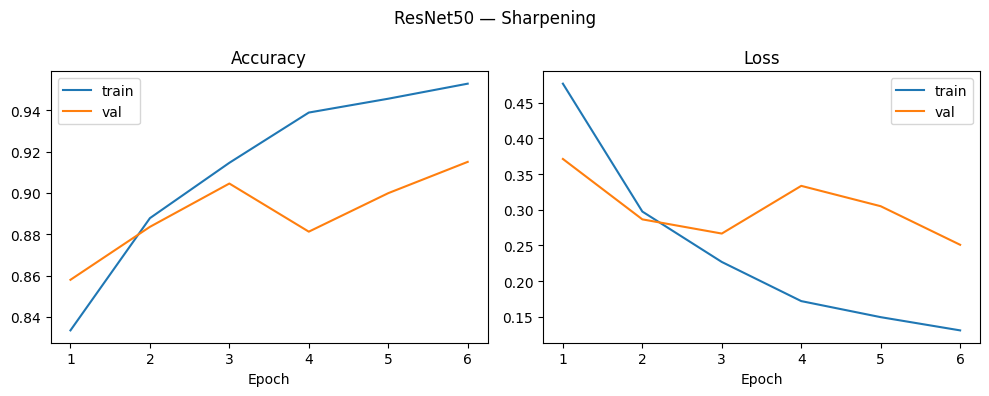


  ResNet50 | Sobel
  [ResNet50 | Sobel] Ep 1/6 | train_loss=0.610 train_acc=0.797 | val_loss=0.515 val_acc=0.814
  [ResNet50 | Sobel] Ep 2/6 | train_loss=0.456 train_acc=0.830 | val_loss=0.488 val_acc=0.821
  [ResNet50 | Sobel] Ep 3/6 | train_loss=0.401 train_acc=0.849 | val_loss=0.442 val_acc=0.832
  [ResNet50 | Sobel] Ep 4/6 | train_loss=0.346 train_acc=0.874 | val_loss=0.436 val_acc=0.837
  [ResNet50 | Sobel] Ep 5/6 | train_loss=0.297 train_acc=0.892 | val_loss=0.450 val_acc=0.829
  [ResNet50 | Sobel] Ep 6/6 | train_loss=0.255 train_acc=0.903 | val_loss=0.433 val_acc=0.852
  RESULT -> {'Accuracy': 84.52, 'Precision': 82.86, 'Recall': 84.52, 'F1-score': 82.64, 'Macro-F1': 57.94, 'Balanced Accuracy': np.float64(52.55), 'AUC': np.float64(91.88)}


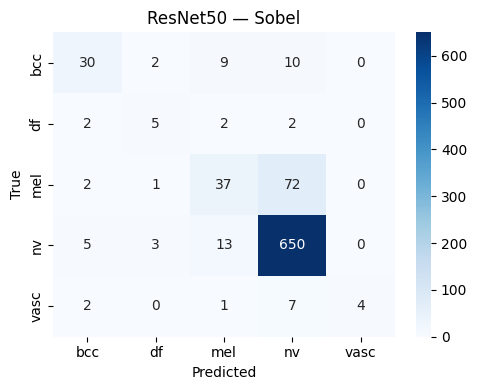

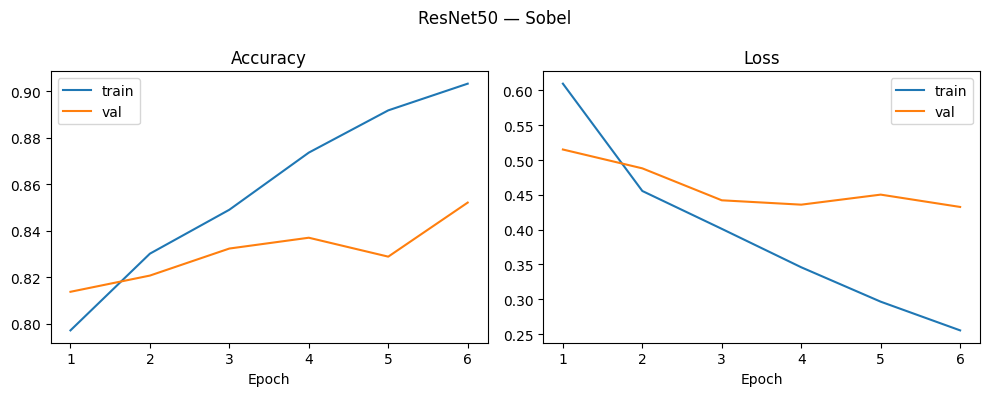


  DenseNet121 | Average
  [DenseNet121 | Average] Ep 1/6 | train_loss=0.458 train_acc=0.833 | val_loss=0.320 val_acc=0.885
  [DenseNet121 | Average] Ep 2/6 | train_loss=0.311 train_acc=0.880 | val_loss=0.291 val_acc=0.902
  [DenseNet121 | Average] Ep 3/6 | train_loss=0.267 train_acc=0.899 | val_loss=0.254 val_acc=0.902
  [DenseNet121 | Average] Ep 4/6 | train_loss=0.227 train_acc=0.913 | val_loss=0.261 val_acc=0.902
  [DenseNet121 | Average] Ep 5/6 | train_loss=0.213 train_acc=0.917 | val_loss=0.333 val_acc=0.877
  [DenseNet121 | Average] Ep 6/6 | train_loss=0.182 train_acc=0.929 | val_loss=0.324 val_acc=0.881
  RESULT -> {'Accuracy': 88.24, 'Precision': 87.51, 'Recall': 88.24, 'F1-score': 87.0, 'Macro-F1': 71.6, 'Balanced Accuracy': np.float64(71.99), 'AUC': np.float64(96.86)}


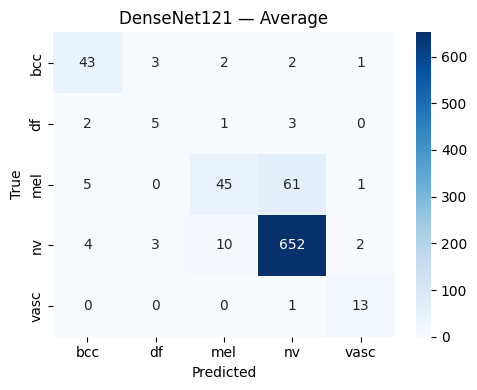

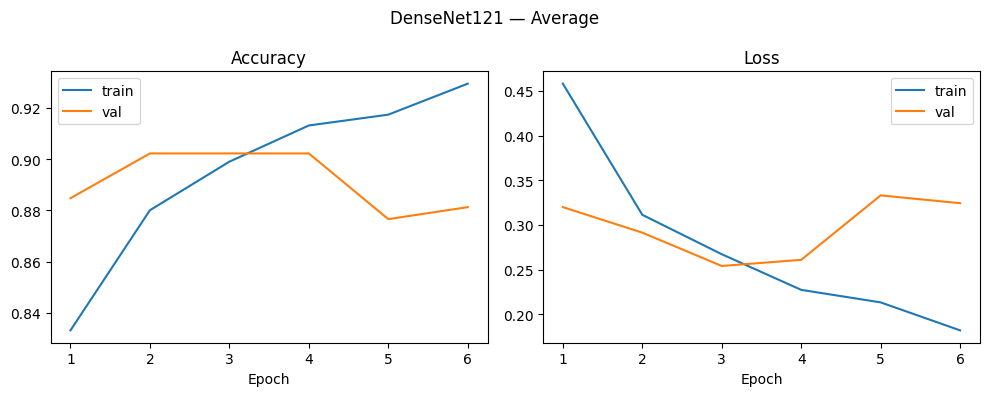


  DenseNet121 | Gaussian
  [DenseNet121 | Gaussian] Ep 1/6 | train_loss=0.445 train_acc=0.838 | val_loss=0.304 val_acc=0.888
  [DenseNet121 | Gaussian] Ep 2/6 | train_loss=0.295 train_acc=0.887 | val_loss=0.286 val_acc=0.886
  [DenseNet121 | Gaussian] Ep 3/6 | train_loss=0.251 train_acc=0.900 | val_loss=0.245 val_acc=0.902
  [DenseNet121 | Gaussian] Ep 4/6 | train_loss=0.218 train_acc=0.916 | val_loss=0.272 val_acc=0.901
  [DenseNet121 | Gaussian] Ep 5/6 | train_loss=0.190 train_acc=0.927 | val_loss=0.230 val_acc=0.912
  [DenseNet121 | Gaussian] Ep 6/6 | train_loss=0.160 train_acc=0.940 | val_loss=0.315 val_acc=0.900
  RESULT -> {'Accuracy': 92.32, 'Precision': 92.07, 'Recall': 92.32, 'F1-score': 91.94, 'Macro-F1': 83.0, 'Balanced Accuracy': np.float64(84.25), 'AUC': np.float64(97.78)}


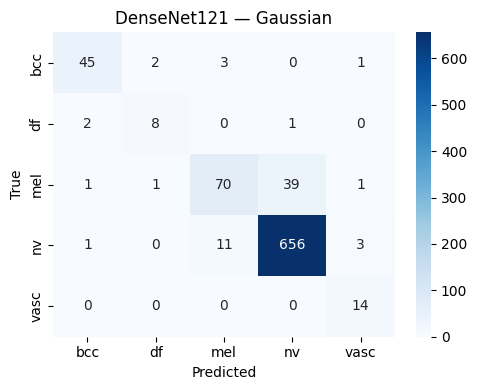

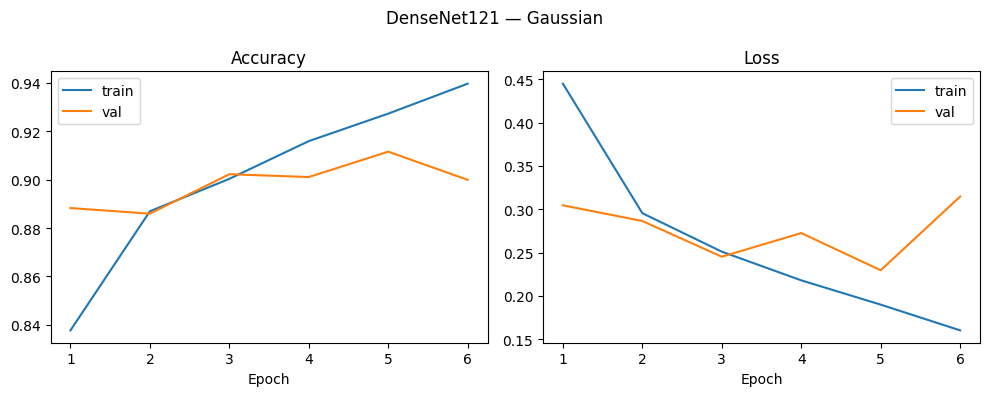


  DenseNet121 | Median
  [DenseNet121 | Median] Ep 1/6 | train_loss=0.449 train_acc=0.833 | val_loss=0.345 val_acc=0.859
  [DenseNet121 | Median] Ep 2/6 | train_loss=0.304 train_acc=0.884 | val_loss=0.258 val_acc=0.901
  [DenseNet121 | Median] Ep 3/6 | train_loss=0.264 train_acc=0.898 | val_loss=0.253 val_acc=0.906
  [DenseNet121 | Median] Ep 4/6 | train_loss=0.226 train_acc=0.912 | val_loss=0.258 val_acc=0.907
  [DenseNet121 | Median] Ep 5/6 | train_loss=0.203 train_acc=0.922 | val_loss=0.305 val_acc=0.891
  [DenseNet121 | Median] Ep 6/6 | train_loss=0.178 train_acc=0.932 | val_loss=0.273 val_acc=0.906
  RESULT -> {'Accuracy': 91.27, 'Precision': 90.94, 'Recall': 91.27, 'F1-score': 90.91, 'Macro-F1': 78.85, 'Balanced Accuracy': np.float64(75.08), 'AUC': np.float64(96.7)}


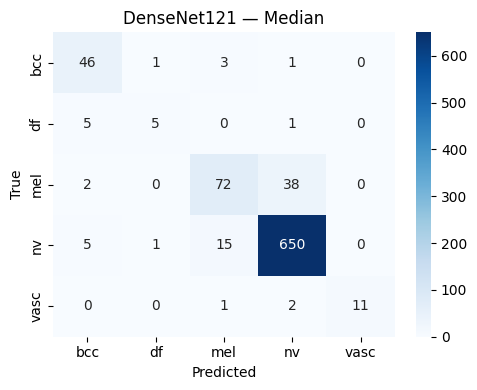

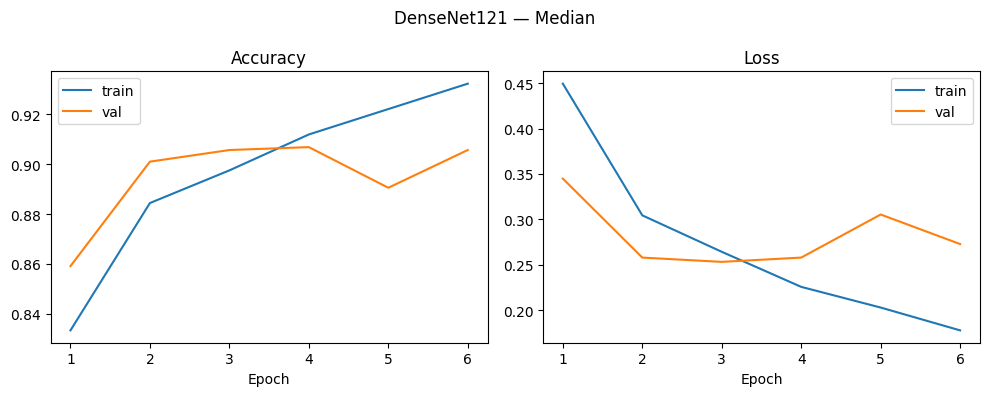


  DenseNet121 | Sharpening
  [DenseNet121 | Sharpening] Ep 1/6 | train_loss=0.427 train_acc=0.845 | val_loss=0.314 val_acc=0.882
  [DenseNet121 | Sharpening] Ep 2/6 | train_loss=0.264 train_acc=0.898 | val_loss=0.251 val_acc=0.909
  [DenseNet121 | Sharpening] Ep 3/6 | train_loss=0.217 train_acc=0.919 | val_loss=0.261 val_acc=0.905
  [DenseNet121 | Sharpening] Ep 4/6 | train_loss=0.189 train_acc=0.927 | val_loss=0.259 val_acc=0.910
  [DenseNet121 | Sharpening] Ep 5/6 | train_loss=0.154 train_acc=0.944 | val_loss=0.246 val_acc=0.906
  [DenseNet121 | Sharpening] Ep 6/6 | train_loss=0.126 train_acc=0.955 | val_loss=0.255 val_acc=0.914
  RESULT -> {'Accuracy': 91.39, 'Precision': 91.02, 'Recall': 91.39, 'F1-score': 91.03, 'Macro-F1': 83.1, 'Balanced Accuracy': np.float64(79.52), 'AUC': np.float64(98.41)}


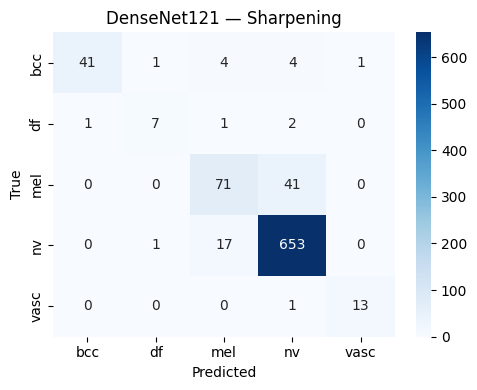

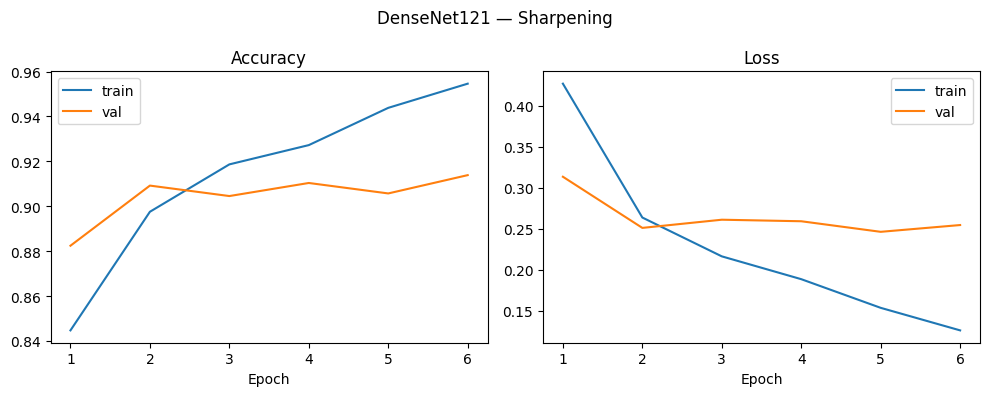


  DenseNet121 | Sobel
  [DenseNet121 | Sobel] Ep 1/6 | train_loss=0.559 train_acc=0.810 | val_loss=0.474 val_acc=0.824
  [DenseNet121 | Sobel] Ep 2/6 | train_loss=0.438 train_acc=0.843 | val_loss=0.440 val_acc=0.847
  [DenseNet121 | Sobel] Ep 3/6 | train_loss=0.389 train_acc=0.859 | val_loss=0.447 val_acc=0.825
  [DenseNet121 | Sobel] Ep 4/6 | train_loss=0.338 train_acc=0.877 | val_loss=0.423 val_acc=0.856
  [DenseNet121 | Sobel] Ep 5/6 | train_loss=0.301 train_acc=0.886 | val_loss=0.430 val_acc=0.834
  [DenseNet121 | Sobel] Ep 6/6 | train_loss=0.260 train_acc=0.904 | val_loss=0.471 val_acc=0.829
  RESULT -> {'Accuracy': 83.7, 'Precision': 83.04, 'Recall': 83.7, 'F1-score': 83.21, 'Macro-F1': 56.06, 'Balanced Accuracy': np.float64(52.4), 'AUC': np.float64(91.98)}


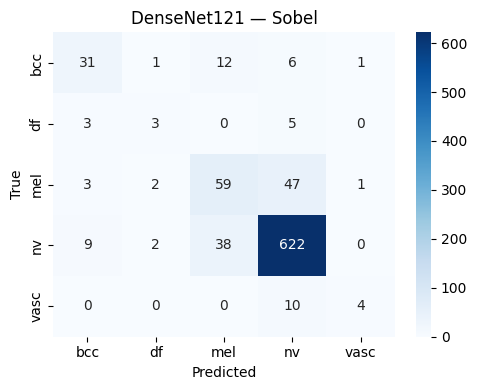

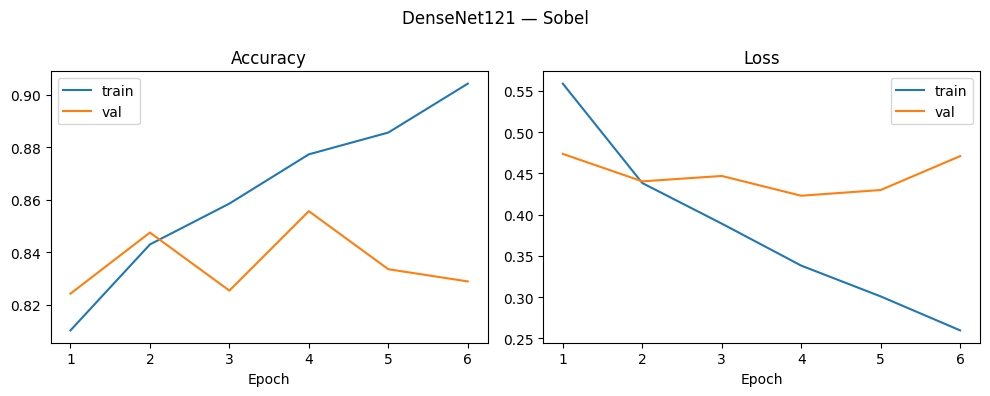


All experiments completed.
Total experiment results: 18
Total per-class records: 90


In [20]:
# ============================================================
# Run all experiments
# ============================================================

# Clear old results so this run starts clean.
results_rows = []
per_class_records = []

# 1. Baseline experiments (No Filter)
for model_name in BEST_MODELS:
    run_experiment(model_name, 'none')

# 2. Filtered experiments
FILTERS_ONLY = [
    filter_name
    for filter_name in FILTER_LABELS
    if filter_name != 'none'
]

for model_name in BEST_MODELS:
    for filter_name in FILTERS_ONLY:
        run_experiment(model_name, filter_name)

print("\nAll experiments completed.")
print(f"Total experiment results: {len(results_rows)}")
print(f"Total per-class records: {len(per_class_records)}")


In [21]:
# ============================================================
# Build and save results tables
# ============================================================

if len(results_rows) == 0:
    raise RuntimeError(
        "No experiment results were generated. "
        "Make sure the 'Run all experiments' cell completed successfully."
    )

results_df = pd.DataFrame(results_rows)

required_result_columns = [
    'Model',
    'Filter',
    'Accuracy',
    'Precision',
    'Recall',
    'F1-score',
    'Macro-F1',
    'Balanced Accuracy',
    'AUC'
]

missing_columns = [
    col for col in required_result_columns
    if col not in results_df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing result columns: {missing_columns}"
    )

results_df.to_csv(
    os.path.join(SAVE_DIR, 'table_results.csv'),
    index=False
)

with open(
    os.path.join(SAVE_DIR, 'table_results.md'),
    'w',
    encoding='utf-8'
) as f:
    f.write(
        "# Task 02 — Results Table\n\n"
        + results_df.to_markdown(index=False)
    )

per_class_df = pd.DataFrame(per_class_records)

per_class_df.to_csv(
    os.path.join(SAVE_DIR, 'per_class_metrics.csv'),
    index=False
)

print("Results saved successfully.")
print(f"Results folder: {SAVE_DIR}")

results_df


Results saved successfully.
Results folder: ./results_task02


,Model,Filter,Accuracy,Precision,Recall,F1-score,Macro-F1,Balanced Accuracy,AUC
0,AlexNet,No Filter,87.89,87.35,87.89,87.15,72.78,72.73,96.77
1,ResNet50,No Filter,91.39,90.99,91.39,90.66,79.77,75.38,97.18
2,DenseNet121,No Filter,90.69,90.63,90.69,90.51,79.58,82.10,97.63
3,AlexNet,Average,88.82,88.20,88.82,88.11,72.60,73.03,97.17
4,AlexNet,Gaussian,88.13,87.31,88.13,86.57,74.21,72.17,97.19
5,AlexNet,Median,88.59,87.58,88.59,87.94,62.88,68.32,97.06
6,AlexNet,Sharpening,88.36,87.85,88.36,87.96,73.45,71.31,96.75
7,AlexNet,Sobel,81.14,78.29,81.14,76.94,39.26,34.72,86.18
8,ResNet50,Average,89.41,89.67,89.41,89.37,80.05,80.95,97.40
9,ResNet50,Gaussian,90.57,89.88,90.57,89.66,83.48,79.99,97.62


In [22]:
# ============================================================
# Comparative Analysis
# ============================================================

def generate_comparative_analysis(results_df):
    lines = ["# Task 02 — Comparative Analysis\n"]

    # Use display labels from the FILTER_LABELS dictionary.
    # This avoids the previous list/dictionary .values() error.
    filter_order = list(FILTER_LABELS.values())

    # Make sure all filters actually present in results are retained.
    filter_order = [
        f for f in filter_order
        if f in results_df['Filter'].unique()
    ]

    baseline_rows = results_df[
        results_df['Filter'] == FILTER_LABELS['none']
    ]

    if baseline_rows.empty:
        raise ValueError("No 'No Filter' baseline results found.")

    baseline = (
        baseline_rows
        .set_index('Model')['Accuracy']
    )

    lines.append(
        "## Accuracy change vs. baseline (No Filter), percentage points\n"
    )

    pivot = (
        results_df
        .pivot(index='Filter', columns='Model', values='Accuracy')
        .reindex(filter_order)
    )

    delta = pivot.subtract(
        baseline,
        axis=1
    )

    lines.append(delta.round(2).to_markdown())

    # Greatest change
    lines.append(
        "\n\n## Which filter caused the greatest change "
        "(avg |delta| across models)?\n"
    )

    filtered_delta = delta.drop(
        index=FILTER_LABELS['none'],
        errors='ignore'
    )

    avg_abs_delta = (
        filtered_delta
        .abs()
        .mean(axis=1)
        .sort_values(ascending=False)
    )

    lines.append(avg_abs_delta.round(2).to_markdown())

    if not avg_abs_delta.empty:
        top_filter = avg_abs_delta.index[0]
        lines.append(
            f"\n**{top_filter}** produced the largest average shift "
            "in accuracy across the three models.\n"
        )

    # Direction consistency
    lines.append(
        "\n## Is the direction of each filter's effect consistent "
        "across models?\n"
    )

    direction = np.sign(filtered_delta)

    for f in direction.index:
        signs = direction.loc[f].dropna()

        if len(signs) == 0:
            continue

        consistent = signs.nunique() == 1

        lines.append(
            f"- **{f}**: "
            f"{'consistent' if consistent else 'NOT consistent'} "
            f"direction across models ({dict(signs)})"
        )

    # Macro-F1 and Balanced Accuracy
    lines.append(
        "\n\n## Macro-F1 and Balanced Accuracy vs. baseline\n"
    )

    for metric in ['Macro-F1', 'Balanced Accuracy']:
        piv = (
            results_df
            .pivot(index='Filter', columns='Model', values=metric)
            .reindex(filter_order)
        )

        base = (
            baseline_rows
            .set_index('Model')[metric]
        )

        d = piv.subtract(
            base,
            axis=1
        )

        lines.append(
            f"### {metric} change vs. baseline\n"
        )

        lines.append(d.round(2).to_markdown())
        lines.append("")

    return "\n".join(lines)


analysis_md = generate_comparative_analysis(results_df)

with open(
    os.path.join(SAVE_DIR, 'comparative_analysis.md'),
    'w',
    encoding='utf-8'
) as f:
    f.write(analysis_md)

print(analysis_md)


# Task 02 — Comparative Analysis

## Accuracy change vs. baseline (No Filter), percentage points

| Filter     |   AlexNet |   DenseNet121 |   ResNet50 |
|:-----------|----------:|--------------:|-----------:|
| No Filter  |      0    |          0    |       0    |
| Average    |      0.93 |         -2.45 |      -1.98 |
| Gaussian   |      0.24 |          1.63 |      -0.82 |
| Median     |      0.7  |          0.58 |      -0.12 |
| Sharpening |      0.47 |          0.7  |       0.58 |
| Sobel      |     -6.75 |         -6.99 |      -6.87 |


## Which filter caused the greatest change (avg |delta| across models)?

| Filter     |    0 |
|:-----------|-----:|
| Sobel      | 6.87 |
| Average    | 1.79 |
| Gaussian   | 0.9  |
| Sharpening | 0.58 |
| Median     | 0.47 |

**Sobel** produced the largest average shift in accuracy across the three models.


## Is the direction of each filter's effect consistent across models?

- **Average**: NOT consistent direction across models ({'AlexNet': np

In [23]:
# ============================================================
# Questions / Answers
# ============================================================

def generate_answers_md(results_df):

    filter_order = list(FILTER_LABELS.values())

    baseline_rows = results_df[
        results_df['Filter'] == FILTER_LABELS['none']
    ]

    if baseline_rows.empty:
        raise ValueError("No 'No Filter' baseline results found.")

    baseline = (
        baseline_rows
        .set_index('Model')['Accuracy']
    )

    accuracy_pivot = (
        results_df
        .pivot(index='Filter', columns='Model', values='Accuracy')
        .reindex(filter_order)
    )

    delta = accuracy_pivot.subtract(
        baseline,
        axis=1
    )

    filtered_delta = delta.drop(
        index=FILTER_LABELS['none'],
        errors='ignore'
    )

    if filtered_delta.empty:
        top_filter = "No filtered results available"
    else:
        top_filter = (
            filtered_delta
            .abs()
            .mean(axis=1)
            .idxmax()
        )

    consistent_filters = []
    inconsistent_filters = []

    for f in filtered_delta.index:
        signs = np.sign(delta.loc[f].dropna())

        if len(signs) == 0:
            continue

        if signs.nunique() == 1:
            consistent_filters.append(f)
        else:
            inconsistent_filters.append(f)

    macro_f1_pivot = (
        results_df
        .pivot(index='Filter', columns='Model', values='Macro-F1')
        .reindex(filter_order)
    )

    macro_f1_baseline = (
        baseline_rows
        .set_index('Model')['Macro-F1']
    )

    macro_f1_delta = macro_f1_pivot.subtract(
        macro_f1_baseline,
        axis=1
    )

    macro_f1_filtered = macro_f1_delta.drop(
        index=FILTER_LABELS['none'],
        errors='ignore'
    )

    if macro_f1_filtered.empty:
        macro_f1_overall = "cannot be determined"
    else:
        macro_f1_overall = (
            "improves"
            if macro_f1_filtered.mean().mean() > 0
            else "decreases"
        )

    best_models_text = ', '.join(BEST_MODELS)

    md_text = f"""# Task 02 — Questions to Answer

**1. Which three pretrained models performed best in Lab Activity 1?**

{best_models_text} (see Task 01 results for exact accuracy figures).

**2. How does filtering affect each of the three models?**

See the per-model columns in `comparative_analysis.md` for the exact percentage-point changes in accuracy for each filter.

**3. Which filter produces the greatest change compared with the unfiltered baseline?**

**{top_filter}**, based on the average absolute accuracy change across the three models.

**4. Does the effect of a filter remain consistent across all three models?**

Consistent direction across all 3 models: {', '.join(consistent_filters) or 'none'}.

Inconsistent direction (models disagreed): {', '.join(inconsistent_filters) or 'none'}.

**5. Does filtering improve or decrease macro-F1 and balanced accuracy?**

On average across models and filters, macro-F1 **{macro_f1_overall}** relative to the unfiltered baseline. See `comparative_analysis.md` for the detailed breakdown.

**6. Which lesion classes are most affected by filtering?**

Compare per-class F1 in `per_class_metrics.csv` between "No Filter" and each filtered result. The class with the largest F1 change is the most filter-sensitive.

**7. Why might smoothing remove useful lesion texture or morphological information?**

Average, Gaussian, and Median filters modify neighboring pixel intensities to smooth an image. Fine lesion details such as texture, pigment patterns, dots, and streaks may contain useful classification information. Strong smoothing can reduce these details while preserving larger shape and color information.

**8. Why might sharpening or edge detection help or hurt classification?**

Sharpening emphasizes edges and high-frequency details, which can make lesion boundaries and textures more visible. However, it can also amplify noise and imaging artifacts. Edge detection emphasizes boundaries but removes much of the original color information.

**9. What is the difference between convolution and correlation?**

Both operations slide a kernel over an image and calculate weighted sums. True convolution flips the kernel horizontally and vertically, while correlation does not. For symmetric kernels, such as Gaussian filters, the results are equivalent. For asymmetric kernels, such as Sobel filters, the results can differ.

**10. What is the relationship between classical image processing and deep-learning-based feature extraction?**

Classical filters use fixed, manually designed kernels to perform operations such as smoothing and edge detection. CNN convolutional layers perform a similar operation, but their kernel weights are learned from data. Therefore, classical preprocessing adds a manually selected image-processing step before the CNN, while the CNN learns task-specific features automatically.
"""

    output_file = os.path.join(
        SAVE_DIR,
        'answers.md'
    )

    with open(
        output_file,
        'w',
        encoding='utf-8'
    ) as f:
        f.write(md_text)

    print(f"Saved: {output_file}")
    print("\n" + md_text)

    return md_text


answers_md = generate_answers_md(results_df)


Saved: ./results_task02/answers.md

# Task 02 — Questions to Answer

**1. Which three pretrained models performed best in Lab Activity 1?**

AlexNet, ResNet50, DenseNet121 (see Task 01 results for exact accuracy figures).

**2. How does filtering affect each of the three models?**

See the per-model columns in `comparative_analysis.md` for the exact percentage-point changes in accuracy for each filter.

**3. Which filter produces the greatest change compared with the unfiltered baseline?**

**Sobel**, based on the average absolute accuracy change across the three models.

**4. Does the effect of a filter remain consistent across all three models?**

Consistent direction across all 3 models: Sharpening, Sobel.

Inconsistent direction (models disagreed): Average, Gaussian, Median.

**5. Does filtering improve or decrease macro-F1 and balanced accuracy?**

On average across models and filters, macro-F1 **decreases** relative to the unfiltered baseline. See `comparative_analysis.md` for th

In [24]:
# ============================================================
# Final validation
# ============================================================

print("Notebook Task 02 validation")
print("-" * 50)
print(f"Models: {BEST_MODELS}")
print(f"Filters: {FILTER_LABELS}")
print(f"Number of experiment rows: {len(results_df)}")
print(f"Expected rows: {len(BEST_MODELS) * len(FILTER_LABELS)}")
print(f"Results saved in: {SAVE_DIR}")

if len(results_df) == len(BEST_MODELS) * len(FILTER_LABELS):
    print("STATUS: All expected experiments are present.")
else:
    print("STATUS: Check experiment output; some expected rows may be missing.")

print("\nGenerated files:")
for filename in [
    'table_results.csv',
    'table_results.md',
    'per_class_metrics.csv',
    'comparative_analysis.md',
    'answers.md'
]:
    path = os.path.join(SAVE_DIR, filename)
    print(f"{'OK' if os.path.exists(path) else 'MISSING'}: {path}")


Notebook Task 02 validation
--------------------------------------------------
Models: ['AlexNet', 'ResNet50', 'DenseNet121']
Filters: {'none': 'No Filter', 'average': 'Average', 'gaussian': 'Gaussian', 'median': 'Median', 'sharpen': 'Sharpening', 'sobel': 'Sobel'}
Number of experiment rows: 18
Expected rows: 18
Results saved in: ./results_task02
STATUS: All expected experiments are present.

Generated files:
OK: ./results_task02/table_results.csv
OK: ./results_task02/table_results.md
OK: ./results_task02/per_class_metrics.csv
OK: ./results_task02/comparative_analysis.md
OK: ./results_task02/answers.md
